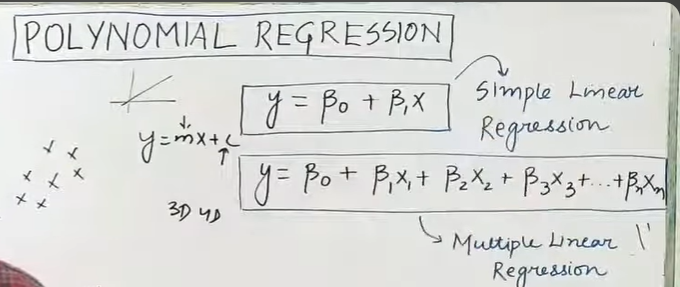

Polynomial regression is actually a form of linear regression where at the end we apply linear regression with same principles but the major diffrence is we apply polynomial terms in data.

In [1]:

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression,SGDRegressor

from sklearn.preprocessing import PolynomialFeatures,StandardScaler

from sklearn.metrics import r2_score

from sklearn.pipeline import Pipeline

In [5]:
#gernrating dataset

X = 6 * np.random.rand(200, 1) - 3
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.randn(200, 1)

# y = 0.8x^2 + 0.9x + 2 this is equation (polynomial of degree: 2)

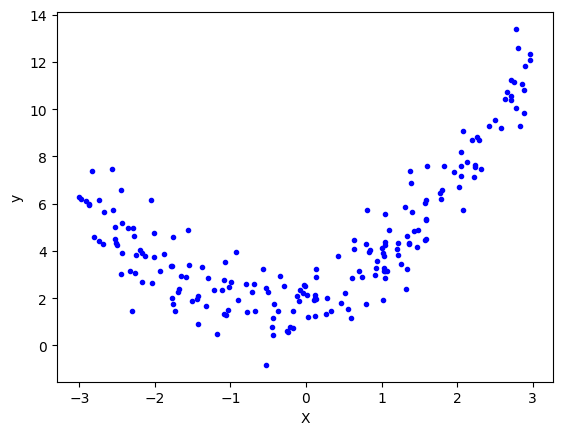

In [6]:

plt.plot(X, y,'b.')
plt.xlabel("X")
plt.ylabel("y")
plt.show()

# Linear Regression

In [7]:
# Train test split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [8]:
# Applying linear regression
lr = LinearRegression()

In [9]:

lr.fit(X_train,y_train)

LinearRegression()

In [10]:
y_pred = lr.predict(X_test)
r2_score(y_test,y_pred)

0.2886949197911951

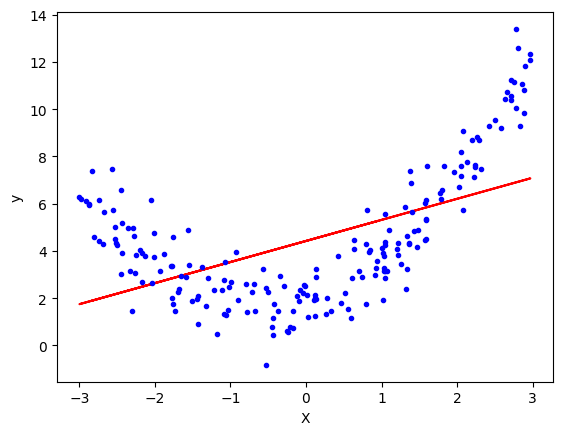

In [11]:
plt.plot(X_train,lr.predict(X_train),color='r')
plt.plot(X, y, "b.")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

# Applying Polynomial Linear Regression

In [16]:
# Create a PolynomialFeatures transformer that generates polynomial terms
# degree=2 → includes all squared terms and interaction terms
# include_bias=True → adds a column of ones (bias term)
poly = PolynomialFeatures(degree=2, include_bias=True)

# Fit the transformer on the training data and transform it.
# This expands X_train to include original features, squared features,
# and pairwise interaction terms.
X_train_trans = poly.fit_transform(X_train)

# Apply the same transformation to the test data without refitting.
# Ensures train and test use the exact same feature mapping.
X_test_trans = poly.transform(X_test)


In [17]:
print(X_train[0])
print(X_train_trans[0])

[-2.8277716]
[ 1.        -2.8277716  7.9962922]


In [14]:
# include_bias parameter

In [15]:

lr = LinearRegression()
lr.fit(X_train_trans,y_train)

LinearRegression()

In [18]:

y_pred = lr.predict(X_test_trans)

In [19]:
r2_score(y_test,y_pred)

0.9001399930855885

In [20]:

print(lr.coef_)
print(lr.intercept_)

[[0.         0.88155805 0.8278466 ]]
[1.96615456]


In [21]:
X_new=np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)

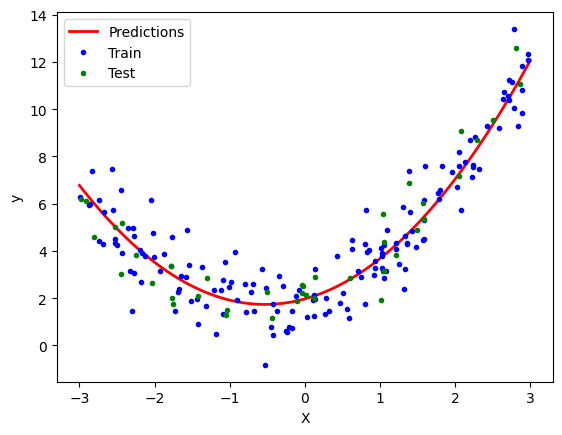

In [22]:
# Plot predictions and data points
plt.plot(X_new, y_new, "r-", lw=2, label="Predictions")
plt.plot(X_train, y_train, "b.", label="Train")
plt.plot(X_test, y_test, "g.", label="Test")
plt.xlabel("X"); plt.ylabel("y")
plt.legend(); plt.show()


In [23]:
def polynomial_regression(degree):
    # Generate new X values for smooth curve
    X_new = np.linspace(-3, 3, 100).reshape(-1, 1)

    # Build a polynomial regression pipeline
    polybig = PolynomialFeatures(degree=degree, include_bias=False)
    scaler = StandardScaler()
    lin_reg = LinearRegression()
    model = Pipeline([
        ("poly_features", polybig),
        ("std_scaler", scaler),
        ("lin_reg", lin_reg),
    ])

    # Fit model and predict on smooth curve
    model.fit(X, y)
    y_pred = model.predict(X_new)

    # Plot curve + data points
    plt.plot(X_new, y_pred, 'r', lw=2, label=f"Degree {degree}")
    plt.plot(X_train, y_train, "b.", label="Train")
    plt.plot(X_test, y_test, "g.", label="Test")
    plt.xlabel("X"); plt.ylabel("y")
    plt.axis([-3, 3, 0, 10])
    plt.legend(); plt.show()


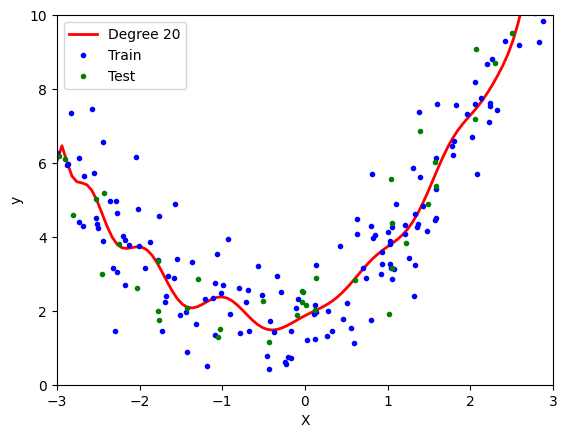

In [26]:

polynomial_regression(20)

In [27]:
poly.powers_

array([[0],
       [1],
       [2]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


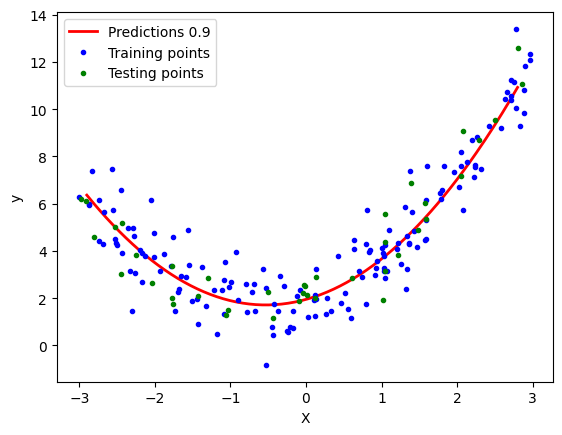

In [28]:

# Applying Gradient Descent

poly = PolynomialFeatures(degree=2)

X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)

sgd = SGDRegressor(max_iter=100)
sgd.fit(X_train_trans,y_train)

X_new=np.linspace(-2.9, 2.8, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = sgd.predict(X_new_poly)

y_pred = sgd.predict(X_test_trans)

plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions " + str(round(r2_score(y_test,y_pred),2)))
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [29]:
# 3D polynomial regression
x = 7 * np.random.rand(100, 1) - 2.8
y = 7 * np.random.rand(100, 1) - 2.8

z = x**2 + y**2 + 0.2*x + 0.2*y + 0.1*x*y +2 + np.random.randn(100, 1)
# z = x^2 + y^2 + 0.2x + 0.2y + 0.1xy + 2

In [30]:
import plotly.express as px
df = px.data.iris()
fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())
fig.show()

In [31]:
lr = LinearRegression()
lr.fit(np.array([x,y]).reshape(100,2),z)

x_input = np.linspace(x.min(), x.max(), 10)
y_input = np.linspace(y.min(), y.max(), 10)
xGrid, yGrid = np.meshgrid(x_input,y_input)

final = np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T

z_final = lr.predict(final).reshape(10,10)

In [32]:
import plotly.graph_objects as go

fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())

fig.add_trace(go.Surface(x = x_input, y = y_input, z =z_final ))

fig.show()

In [33]:
X_multi = np.array([x,y]).reshape(100,2)
X_multi.shape

(100, 2)

In [37]:
poly = PolynomialFeatures(degree=30)
x_multi_trans = poly.fit_transform(X_multi)

print("Input features:", poly.n_features_in_)
print("Output features:", poly.n_output_features_)
print("Powers:\n", poly.powers_)


Input features: 2
Output features: 496
Powers:
 [[ 0  0]
 [ 1  0]
 [ 0  1]
 [ 2  0]
 [ 1  1]
 [ 0  2]
 [ 3  0]
 [ 2  1]
 [ 1  2]
 [ 0  3]
 [ 4  0]
 [ 3  1]
 [ 2  2]
 [ 1  3]
 [ 0  4]
 [ 5  0]
 [ 4  1]
 [ 3  2]
 [ 2  3]
 [ 1  4]
 [ 0  5]
 [ 6  0]
 [ 5  1]
 [ 4  2]
 [ 3  3]
 [ 2  4]
 [ 1  5]
 [ 0  6]
 [ 7  0]
 [ 6  1]
 [ 5  2]
 [ 4  3]
 [ 3  4]
 [ 2  5]
 [ 1  6]
 [ 0  7]
 [ 8  0]
 [ 7  1]
 [ 6  2]
 [ 5  3]
 [ 4  4]
 [ 3  5]
 [ 2  6]
 [ 1  7]
 [ 0  8]
 [ 9  0]
 [ 8  1]
 [ 7  2]
 [ 6  3]
 [ 5  4]
 [ 4  5]
 [ 3  6]
 [ 2  7]
 [ 1  8]
 [ 0  9]
 [10  0]
 [ 9  1]
 [ 8  2]
 [ 7  3]
 [ 6  4]
 [ 5  5]
 [ 4  6]
 [ 3  7]
 [ 2  8]
 [ 1  9]
 [ 0 10]
 [11  0]
 [10  1]
 [ 9  2]
 [ 8  3]
 [ 7  4]
 [ 6  5]
 [ 5  6]
 [ 4  7]
 [ 3  8]
 [ 2  9]
 [ 1 10]
 [ 0 11]
 [12  0]
 [11  1]
 [10  2]
 [ 9  3]
 [ 8  4]
 [ 7  5]
 [ 6  6]
 [ 5  7]
 [ 4  8]
 [ 3  9]
 [ 2 10]
 [ 1 11]
 [ 0 12]
 [13  0]
 [12  1]
 [11  2]
 [10  3]
 [ 9  4]
 [ 8  5]
 [ 7  6]
 [ 6  7]
 [ 5  8]
 [ 4  9]
 [ 3 10]
 [ 2 11]
 [ 1 12]
 [ 0 13]
 [14  0

In [38]:

X_multi_trans.shape

(100, 496)

In [39]:
lr = LinearRegression()
lr.fit(X_multi_trans,z)

LinearRegression()

In [40]:
X_test_multi = poly.transform(final)

In [41]:

z_final = lr.predict(X_multi_trans).reshape(10,10)

In [42]:

fig = px.scatter_3d(x=x.ravel(), y=y.ravel(), z=z.ravel())

fig.add_trace(go.Surface(x = x_input, y = y_input, z =z_final))

fig.update_layout(scene = dict(zaxis = dict(range=[0,35])))

fig.show()